In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parents[1] / "02_python" / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from load_data import load_all_tables

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

tables = load_all_tables()

# Fixes carried forward from profiling:
# - review analysis keys on order_id, not review_id (review_id not unique)
# - category names need translating from Portuguese
orders = tables["orders"].copy()
order_items = tables["order_items"].copy()
reviews = tables["reviews"].copy()
customers = tables["customers"].copy()
products = tables["products"].merge(
    tables["category_translation"], on="product_category_name", how="left"
)
sellers = tables["sellers"].copy()
payments = tables["payments"].copy()

for col in ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]:
    orders[col] = pd.to_datetime(orders[col])

print("Loaded and prepped.")

Loaded and prepped.


## Business questions

Six questions, each closing with a business finding, not just a chart.
Framing: you're the first analyst hired by this marketplace — leadership
wants to know why customers aren't returning and whether delivery is
costing them.

**Q1 — Revenue concentration:** which categories drive revenue vs. volume?

In [3]:
items_products = order_items.merge(
    products[["product_id", "product_category_name_english"]], on="product_id", how="left"
)

category_revenue = (
    items_products.groupby("product_category_name_english")
    .agg(revenue=("price", "sum"), orders=("order_id", "nunique"))
    .sort_values("revenue", ascending=False)
)

category_revenue["revenue_pct"] = category_revenue["revenue"] / category_revenue["revenue"].sum() * 100
category_revenue["cumulative_pct"] = category_revenue["revenue_pct"].cumsum()

top10_share = category_revenue.head(10)["revenue_pct"].sum()
n_categories = len(category_revenue)

print(f"Top 10 of {n_categories} categories account for {top10_share:.1f}% of revenue")
category_revenue.head(10)

Top 10 of 71 categories account for 63.2% of revenue


,revenue,orders,revenue_pct,cumulative_pct
product_category_name_english,,,,
health_beauty,1258681.34,8836,9.388524,9.388524
watches_gifts,1205005.68,5624,8.988157,18.376681
bed_bath_table,1036988.68,9417,7.734915,26.111596
sports_leisure,988048.97,7720,7.369873,33.481470
computers_accessories,911954.32,6689,6.802282,40.283752
furniture_decor,729762.49,6449,5.443310,45.727062
cool_stuff,635290.85,3632,4.738645,50.465706
housewares,632248.66,5884,4.715953,55.181659
auto,592720.11,3897,4.421109,59.602768


**Finding:** the top 10 categories (of 71) generate 63.2% of revenue — concentrated
but not extreme. `health_beauty`, `watches_gifts` and `bed_bath_table` alone account
for over a quarter of total revenue (26.1%).

**So what:** revenue isn't dependent on a handful of categories, but a commercial
team optimising inventory, marketing spend or seller support would get outsized
return focusing on the top 10 — they're worth ~2.7x their "fair share" if revenue
were spread evenly across 71 categories.

**Q2 — Delivery vs. satisfaction:** does late delivery actually lower review
scores, and by how much? Scoped to delivered orders only, per the decision
logged in `docs/decisions_log.md`. Review analysis keyed on `order_id`, not
`review_id` (per profiling finding — `review_id` not unique).

In [4]:
delivered = orders[orders["order_status"] == "delivered"].copy()
delivered = delivered.dropna(subset=["order_delivered_customer_date", "order_estimated_delivery_date"])

delivered["delay_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"]
).dt.days

def bucket_delay(days):
    if days <= -1:
        return "early"
    elif days == 0:
        return "on_time"
    elif 1 <= days <= 3:
        return "1-3 days late"
    else:
        return "4+ days late"

delivered["delivery_bucket"] = delivered["delay_days"].apply(bucket_delay)

# Reviews keyed on order_id — drop duplicate order_id rows first (keep first),
# since ~550 orders have multiple review rows (per Excel first-look)
reviews_dedup = reviews.drop_duplicates(subset="order_id", keep="first")

delivery_reviews = delivered.merge(
    reviews_dedup[["order_id", "review_score"]], on="order_id", how="inner"
)

bucket_order = ["early", "on_time", "1-3 days late", "4+ days late"]
summary = (
    delivery_reviews.groupby("delivery_bucket")
    .agg(avg_review_score=("review_score", "mean"), order_count=("order_id", "count"))
    .reindex(bucket_order)
)
summary["pct_of_orders"] = summary["order_count"] / summary["order_count"].sum() * 100

summary

,avg_review_score,order_count,pct_of_orders
delivery_bucket,,,
early,4.294500,88163,92.005134
on_time,4.030469,1280,1.335782
1-3 days late,3.291037,1852,1.932710
4+ days late,1.854714,4529,4.726373


**Finding:** review scores fall sharply and consistently as delivery lateness
increases — 4.29 average for early orders, down to 3.29 for 1–3 days late,
and 1.85 for orders 4+ days late. That's a drop of nearly 2.5 stars between
the best and worst bucket.

4,529 orders (4.7% of delivered orders) arrived 4+ days late — a small share
of volume, but each one is landing at an average review score under 2 stars,
which is the range that drives public negative reviews and return-customer loss.

**So what:** delivery lateness isn't a minor operational metric — it's the
single clearest driver of dissatisfaction found in this dataset. A marketplace
prioritising retention should treat "4+ days late" as its own SLA breach
category, not lump it in with "late" generally, since the satisfaction cliff
is steep and localised to that group specifically. At ~4,500 orders, this is
a small enough population to intervene on directly (e.g. proactive
compensation or communication) rather than requiring a system-wide fix.

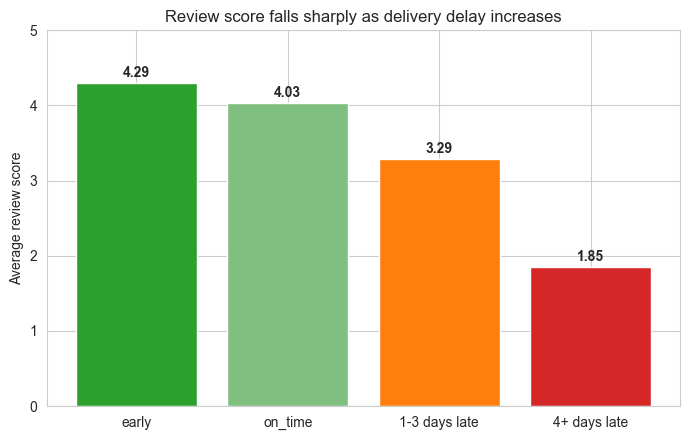

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#2ca02c", "#7fbf7f", "#ff7f0e", "#d62728"]
ax.bar(summary.index, summary["avg_review_score"], color=colors)
ax.set_ylabel("Average review score")
ax.set_title("Review score falls sharply as delivery delay increases")
ax.set_ylim(0, 5)
for i, v in enumerate(summary["avg_review_score"]):
    ax.text(i, v + 0.08, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/delivery_delay_vs_review_score.png", dpi=150)
plt.show()

**Q3 — Repeat purchase rate:** what share of customers order more than once?
Keyed on `customer_unique_id`, not `customer_id` — per the finding from the
Excel first look, `customer_id` is generated fresh per order and would show
a false 0% repeat rate.

In [6]:
orders_with_customer = orders.merge(
    customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left"
)

orders_per_customer = (
    orders_with_customer.groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

total_customers = len(orders_per_customer)
repeat_customers = (orders_per_customer["order_count"] > 1).sum()
repeat_rate = repeat_customers / total_customers * 100

print(f"Total unique customers: {total_customers:,}")
print(f"Customers with more than one order: {repeat_customers:,}")
print(f"Repeat purchase rate: {repeat_rate:.2f}%")

orders_per_customer["order_count"].value_counts().sort_index().head(10)

Total unique customers: 96,096
Customers with more than one order: 2,997
Repeat purchase rate: 3.12%


order_count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

**Finding:** only 3.12% of customers (2,997 of 96,096) place more than one
order. The overwhelming majority — 93,099 customers — buy exactly once. The
distribution drops off sharply after 2 orders, with a single outlier at 17
orders, almost certainly a business/reseller account rather than a typical
retail customer.

**So what:** this marketplace is running on near-total customer acquisition,
not retention — a 3% repeat rate is low for e-commerce generally, where
repeat purchase is usually a primary growth lever. Combined with the delivery
finding above, there's a plausible link worth flagging to leadership: if 4.7%
of orders are landing 4+ days late and scoring under 2 stars, poor delivery
experience is a reasonable contributing factor to why customers aren't coming
back. This project doesn't prove causation, but it puts two real numbers next
to each other that leadership hasn't seen side by side before.

**Q4 — Seller concentration:** what share of revenue comes from the top 10%
of sellers?

In [7]:
seller_revenue = (
    order_items.groupby("seller_id")
    .agg(revenue=("price", "sum"), orders=("order_id", "nunique"))
    .sort_values("revenue", ascending=False)
)

total_sellers = len(seller_revenue)
top10pct_n = max(1, round(total_sellers * 0.10))

top10pct_revenue_share = seller_revenue.head(top10pct_n)["revenue"].sum() / seller_revenue["revenue"].sum() * 100

print(f"Total sellers: {total_sellers:,}")
print(f"Top 10% of sellers ({top10pct_n:,} sellers) generate {top10pct_revenue_share:.1f}% of revenue")

seller_revenue.head(10)

Total sellers: 3,095
Top 10% of sellers (310 sellers) generate 67.6% of revenue


,revenue,orders
seller_id,,
4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132
53243585a1d6dc2643021fd1853d8905,222776.05,358
4a3ca9315b744ce9f8e9374361493884,200472.92,1806
fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585
7c67e1448b00f6e969d365cea6b010ab,187923.89,982
7e93a43ef30c4f03f38b393420bc753a,176431.87,336
da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314
7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160
1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915


**Finding:** the top 10% of sellers (310 of 3,095) generate 67.6% of total
revenue — more concentrated than the category split (top 10 of 71 categories
drove 63.2%). The top single seller alone accounts for $229K across 1,132
orders.

**So what:** this is a seller-dependency risk, not just a performance
observation. If any of the top handful of sellers churned off the platform,
the revenue impact would be immediate and large — a marketplace this
concentrated should be actively monitoring retention and satisfaction for
its top sellers specifically, not just its top categories. Worth cross-
referencing against delivery performance: if a high-revenue seller is also
driving a disproportionate share of late deliveries, that's a single point
of failure worth flagging directly.

**Q5 — Freight cost by category:** which categories have freight eating
the most into item price? Aggregate freight-to-price ratio was ~22.6%
in the Excel first look — breaking it down by category to see whether
that's evenly spread or concentrated.

In [8]:
items_products_freight = order_items.merge(
    products[["product_id", "product_category_name_english"]], on="product_id", how="left"
)

category_freight = (
    items_products_freight.groupby("product_category_name_english")
    .agg(total_price=("price", "sum"), total_freight=("freight_value", "sum"), items=("order_id", "count"))
)
category_freight["freight_pct_of_price"] = category_freight["total_freight"] / category_freight["total_price"] * 100

# only look at categories with meaningful volume, so a 3-item category doesn't distort the ranking
category_freight_meaningful = category_freight[category_freight["items"] >= 100]

worst_freight = category_freight_meaningful.sort_values("freight_pct_of_price", ascending=False)

print(f"Aggregate freight-to-price ratio: {(category_freight['total_freight'].sum() / category_freight['total_price'].sum() * 100):.1f}%")
print(f"\nHighest freight burden (categories with 100+ items):")
worst_freight.head(8)[["freight_pct_of_price", "items", "total_price"]]

Aggregate freight-to-price ratio: 16.6%

Highest freight burden (categories with 100+ items):


,freight_pct_of_price,items,total_price
product_category_name_english,,,
christmas_supplies,36.693172,153,8800.82
signaling_and_security,30.255941,199,21509.23
food_drink,29.697921,278,15179.48
electronics,29.066626,2767,160246.74
furniture_living_room,26.072355,503,68916.56
kitchen_dining_laundry_garden_furniture,25.900825,281,46328.37
drinks,25.597783,379,22428.70
office_furniture,25.029849,1691,273960.70


**Finding:** the aggregate freight-to-price ratio computed here is 16.6% —
lower than the ~22.6% estimated in the Excel first look. The Excel figure
was a simple ratio of two column sums viewed in isolation; this version
sums freight and price per category first, weighted by actual item volume,
which is the more reliable business metric. Noted as a methodology
correction, logged in `docs/decisions_log.md`.

By category, freight burden is far from evenly spread: `christmas_supplies`
sits at 36.7% of item price, more than double the overall average, and
`electronics` — a high-volume category with $160K in item price — carries
29.1%, nearly double the aggregate rate on real scale.

**So what:** freight cost isn't a flat operational overhead — it's a
category-specific margin problem. `electronics` combines high volume with
high freight burden, making it the strongest candidate for a shipping-cost
review (bulkier/heavier items, or a pricing structure that doesn't reflect
delivery cost). Categories like `christmas_supplies` have the worst ratio
but low volume, so any fix there matters less to the bottom line.

**Q6 — Late delivery by geography:** are delays clustered in particular states?

In [9]:
delivered_with_state = delivered.merge(
    customers[["customer_id", "customer_state"]], on="customer_id", how="left"
)

state_delay = (
    delivered_with_state.groupby("customer_state")
    .agg(
        orders=("order_id", "count"),
        late_orders=("delivery_bucket", lambda x: (x == "4+ days late").sum()),
    )
)
state_delay["late_pct"] = state_delay["late_orders"] / state_delay["orders"] * 100

# only states with meaningful volume
state_delay_meaningful = state_delay[state_delay["orders"] >= 100].sort_values("late_pct", ascending=False)

print(f"National late rate (4+ days): {(delivered['delivery_bucket'] == '4+ days late').mean() * 100:.1f}%")
print(f"\nWorst states (100+ orders):")
state_delay_meaningful.head(8)

National late rate (4+ days): 4.8%

Worst states (100+ orders):


,orders,late_orders,late_pct
customer_state,,,
AL,397,69,17.380353
SE,335,43,12.835821
MA,717,92,12.831241
CE,1279,146,11.415168
PI,476,47,9.873950
RJ,12350,1198,9.700405
PA,946,90,9.513742
BA,3256,303,9.305897


**Finding:** late delivery is not evenly distributed — AL sits at 17.4% of
orders arriving 4+ days late, more than 3.5x the national rate of 4.8%. Six
of the eight worst states are more than double the national average. RJ is
the standout on volume: 12,350 orders with a 9.7% late rate — nearly double
the national rate on real scale, not a small-sample outlier.

**So what:** this isn't a uniform delivery problem, it's a regional
logistics problem. A fix targeted at the carrier routes or fulfilment
process serving AL, SE, MA, CE and RJ would address a disproportionate
share of the dissatisfaction found in Q2, without needing to rebuild
delivery operations nationally.

## Summary — findings

1. **Revenue is concentrated but not extreme.** Top 10 of 71 categories
   drive 63.2% of revenue.
2. **Delivery lateness is the strongest satisfaction driver found.** Review
   scores fall from 4.29 (early) to 1.85 (4+ days late) — a 2.4-star drop.
   4.7% of orders fall into that worst bucket.
3. **Repeat purchase rate is low — 3.12%.** 93,099 of 96,096 customers buy
   exactly once. Plausibly connected to the delivery finding above.
4. **Seller revenue is more concentrated than category revenue.** Top 10%
   of sellers (310) generate 67.6% of revenue — a single-seller dependency
   risk.
5. **Freight burden is category-specific, not flat.** Aggregate 16.6%
   (corrected from an initial 22.6% estimate — see decisions log).
   `electronics` combines high volume and high freight burden (29.1%),
   the strongest candidate for a shipping-cost review.
6. **Late delivery clusters geographically.** AL, SE, MA, CE and RJ all
   run at 2–3.5x the 4.8% national late rate — a targeted fix, not a
   national one.

**Connected narrative for leadership:** delivery performance (finding 2) is
concentrated in specific regions (finding 6) and is plausibly linked to the
low repeat-purchase rate (finding 3) — three findings that individually look
like separate metrics but together point at one lever worth prioritising.